In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import minimize
from scipy.optimize import brentq  # For robust root-finding
from scipy.stats import norm


import sys 
sys.path.append('../')
from bin.dbm import DBManager
from bin.main import Manager 
from bin.options.bsm.bs import bs_df
from models.densityEstimation.iter1.curve_fitting import bspline, smoothing_spline

2026-02-22 16:00:20 - INFO - Loaded 19 database connections from environment
2026-02-22 16:00:20 - ERROR - Ticker file not found: data/stocks/tickers.json
2026-02-22 16:00:20 - WARNING - Failed to load tickers: [Errno 2] No such file or directory: 'data/stocks/tickers.json'


In [2]:
dbm = DBManager().for_notebook()
manager = Manager(dbm = dbm)
stock = manager.get_stock_data('spy')
price_data = stock.price_data.daily_df
option_chain =  stock.options.option_chain_on(chain_date = '2026-02-20', use_cache = False)
# option_chain = stock.options.atm_chain_df

2026-02-22 16:00:20 - INFO - Loaded 19 database connections from environment
2026-02-22 16:00:20 - ERROR - Ticker file not found: data/stocks/tickers.json
2026-02-22 16:00:20 - WARNING - Failed to load tickers: [Errno 2] No such file or directory: 'data/stocks/tickers.json'
2026-02-22 16:00:20 - INFO - All connections cleared
2026-02-22 16:00:20 - INFO - Resolved 18 relative paths to absolute paths for project root: /Users/jerald/Documents/Dir/Python/Stocks
2026-02-22 16:00:20 - INFO - Loaded 19 database connections from environment


In [8]:
import numpy as np
from scipy.optimize import minimize
from scipy.stats import norm
from scipy.integrate import trapz
import matplotlib.pyplot as plt

# Step 1: Heston Characteristic Function (vectorized over phi)
def heston_charfunc(phi, v0, kappa, theta, xi, rho, lambd, tau, r):
    a = kappa * theta
    b = kappa + lambd
    rspi = rho * xi * phi * 1j

    d = np.sqrt((rspi - b)**2 + (phi * 1j + phi**2) * xi**2)
    g = (b - rspi + d) / (b - rspi - d)

    exp1 = np.exp(r * phi * 1j * tau)
    term2 = ((1 - g * np.exp(d * tau)) / (1 - g)) ** (-2 * a / xi**2)
    exp2 = np.exp(
        a * tau * (b - rspi + d) / xi**2 +
        v0 * (b - rspi + d) * (1 - np.exp(d * tau)) / (xi**2 * (1 - g * np.exp(d * tau)))
    )

    return exp1 * term2 * exp2

# Step 2: Vectorized BS Call Price (for IV inverter)
def bs_price(S0, K, tau, r, sigma, q=0.0, is_call=True):
    """
    Vectorized Black-Scholes price — is_call can be scalar or array
    """
    S0 = np.asarray(S0)
    K = np.asarray(K)
    tau = np.asarray(tau)
    r = np.asarray(r)
    sigma = np.asarray(sigma)
    q = np.asarray(q)
    is_call = np.asarray(is_call)  # allow array or scalar

    d1 = (np.log(S0 / K) + (r - q + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)

    call_price = S0 * np.exp(-q * tau) * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)
    put_price  = K * np.exp(-r * tau) * norm.cdf(-d2) - S0 * np.exp(-q * tau) * norm.cdf(-d1)

    # Use np.where to select per element if is_call is array
    return np.where(is_call, call_price, put_price)


# Step 3: Vectorized BS IV Inverter (Newton-Raphson)
def vectorized_bs_iv(prices, S0, K, tau, r, q=0.0, is_call=True, max_iv=5.0, tol=1e-6, max_iter=50):
    prices = np.asarray(prices)
    K = np.asarray(K)
    is_call = np.asarray(is_call) if isinstance(is_call, np.ndarray) else np.full_like(prices, is_call, dtype=bool)

    sigma = np.full_like(prices, 0.3)
    sqrt_tau = np.sqrt(tau)
    for _ in range(max_iter):
        d1 = (np.log(S0 / K) + (r - q + 0.5 * sigma**2) * tau) / (sigma * sqrt_tau)
        d2 = d1 - sigma * sqrt_tau

        model_price = bs_price(S0, K, tau, r, sigma, q, is_call)
        vega = S0 * np.exp(-q * tau) * norm.pdf(d1) * sqrt_tau

        error = model_price - prices
        delta_sigma = error / vega
        delta_sigma = np.clip(delta_sigma, -0.5, 0.5)
        sigma -= delta_sigma

        if np.all(np.abs(delta_sigma) < tol):
            break

    sigma = np.clip(sigma, 1e-6, max_iv)
    sigma[vega < 1e-4] = np.nan
    return sigma

# Step 4: Damped P1/P2 Heston Pricing (vectorized, stable for short tau)
def heston_call_price_damped(
    S0, K, v0, kappa, theta, xi, rho, lambd, tau, r,
    q=0.0, alpha=.05, N=8192, umax=1000
):
    K = np.atleast_1d(K)
    phi = np.linspace(1e-5, umax, N)[:, np.newaxis]  # (N, 1)

    # Damped integrand P1
    def integrand_P1(phi):
        char = heston_charfunc(phi - (alpha + 1)*1j, v0, kappa, theta, xi, rho, lambd, tau, r)
        logK = np.log(K[np.newaxis, :])  # (1, n_strikes)
        exp_part = np.exp(-1j * phi * logK)  # (N, n_strikes)
        numer = exp_part * char
        denom = alpha**2 + alpha - phi**2 + 1j * phi * (2*alpha + 1)
        return np.real(numer / denom)

    # Damped integrand P2
    def integrand_P2(phi):
        char = heston_charfunc(phi - alpha*1j, v0, kappa, theta, xi, rho, lambd, tau, r)
        logK = np.log(K[np.newaxis, :])  # (1, n_strikes)
        exp_part = np.exp(-1j * phi * logK)  # (N, n_strikes)
        numer = exp_part * char
        denom = alpha**2 + alpha - phi**2 + 1j * phi
        return np.real(numer / denom)

    # Trapz with unsqueezed phi
    P1_int = trapz(integrand_P1(phi), phi.squeeze(), axis=0)
    P2_int = trapz(integrand_P2(phi), phi.squeeze(), axis=0)

    # Call price (undamp)
    call = S0 * np.exp(-q * tau) * (0.5 + P1_int / np.pi) - K * np.exp(-r * tau) * (0.5 + P2_int / np.pi)
    call = np.exp(-alpha * np.log(K)) * call  # undamp correction

    return np.maximum(call, 0)

# Step 5: Calibration Function (IV-based)
def calibrate_heston_to_chain(strikes, market_prices, S0, tau, r, q=0.0, initial_params=None, lambd=0.0, alpha = 0.05, N = 8192, umax = 1000, weight_type = 'atm'):
    if initial_params is None:
        initials = [
            [3.5, 0.035, 0.025, -0.75, 0.45],
            [5.0, 0.02, 0.015, -0.85, 0.35],
            [2.0, 0.05, 0.03, -0.6, 0.6]
            ]
    def objective(p):
        kappa, theta, v0, rho, xi = p
        
        # Reject invalid params
        if v0 <= 0 or theta <= 0 or xi <= 0 or kappa <= 0 or 2*kappa*theta <= xi**2 + 1e-6:
            return 1e12

        model_prices = heston_call_price_damped(S0, strikes, v0, kappa, theta, xi, rho, lambd, tau, r, q=q, alpha=alpha, N=N, umax=umax)
        
        # Compute market IVs with parity adjustment
        market_ivs = np.full_like(strikes, np.nan)
        mask_call = strikes >= S0
        market_ivs[mask_call] = vectorized_bs_iv(market_prices[mask_call], S0, strikes[mask_call], tau, r, q, is_call=True)
        mask_put = strikes < S0
        if np.any(mask_put):
            put_prices_market = market_prices[mask_put] - S0 * np.exp(-q * tau) + strikes[mask_put] * np.exp(-r * tau)
            market_ivs[mask_put] = vectorized_bs_iv(put_prices_market, S0, strikes[mask_put], tau, r, q, is_call=False)
        
        # Compute model IVs with parity adjustment
        model_ivs = np.full_like(strikes, np.nan)
        model_ivs[mask_call] = vectorized_bs_iv(model_prices[mask_call], S0, strikes[mask_call], tau, r, q, is_call=True)
        if np.any(mask_put):
            put_prices_model = model_prices[mask_put] - S0 * np.exp(-q * tau) + strikes[mask_put] * np.exp(-r * tau)
            model_ivs[mask_put] = vectorized_bs_iv(put_prices_model, S0, strikes[mask_put], tau, r, q, is_call=False)

        valid = np.isfinite(model_ivs) & np.isfinite(market_ivs)
        if not np.any(valid):
            return 1e12

        errors = (model_ivs[valid] - market_ivs[valid]) ** 2

        dist = np.abs(strikes[valid] - S0) / S0
        if weight_type == 'atm':
            weights = 1 / (dist + 0.01) ** 0.5
        elif weight_type == 'tail':
            weights = np.exp(dist * 1.5) + 0.5  # Note: exp(+dist) to emphasize tails more
        else:
            weights = np.ones_like(dist)

        weights = weights / weights.max()

        weighted_errors = weights * errors
        weighted_rmse = np.sqrt(np.sum(weighted_errors) / np.sum(weights))

        # Penalties (optional)
        theta_pen = 5.0 * (theta - 0.02)**2
        rho_pen = 10.0 * (rho + 0.75)**2
        total_penalty = theta_pen + rho_pen

        final_score = weighted_rmse + total_penalty

        print(f"Weighted IV RMSE ({weight_type}): {weighted_rmse:.4f} | Total: {final_score:.4f} | Params: {p.round(4)}")
        return final_score


    bounds = [
    (0.1, 15.0),     # kappa wider
    (0.005, 0.15),   # theta up to higher vol
    (0.005, 0.15),   # v0
    (-0.98, -0.1),   # rho
    (0.5, 2.5)      # xi
    ]

    # result = minimize(objective, initial_params, bounds=bounds, method='Nelder-Mead', options={'maxiter': 1000, 'disp': True})
    # result = minimize(objective, initial_params, bounds=bounds, method='Powell', options={'maxiter': 2000, 'disp': True})
    # result = minimize(objective, initial_params, bounds=bounds, method='Powell',options={'maxiter': 2000, 'xtol': 1e-8, 'ftol': 1e-8, 'disp': True})

    best_rmse, best_params = float('inf'), None
    for init in initials:
        res = minimize(objective, init, bounds=bounds, method='Powell', options={'maxiter': 2000, 'xtol': 1e-8, 'ftol': 1e-8, 'disp': True})
        if res.fun < best_rmse:
            best_rmse, best_params = res.fun, res.x


    return best_params, best_rmse




# Step 6: PDF Extraction Function
from scipy.interpolate import UnivariateSpline

def extract_pdf(strikes, prices, r, tau, s = 0.05, k = 4):
    # Sort strikes/prices (just in case)
    sort_idx = np.argsort(strikes)
    strikes = strikes[sort_idx]
    prices = prices[sort_idx]

    # Smoother spline with lower s for more curvature
    spl = UnivariateSpline(strikes, prices, s=s, k=k)  # quartic, less smoothing

    # Finer grid for deriv to avoid artifacts
    fine_strikes = np.linspace(strikes.min(), strikes.max(), 1000)
    second_deriv = spl.derivative(n=2)(fine_strikes)

    # PDF
    pdf = np.exp(r * tau) * second_deriv
    pdf = np.maximum(pdf, 0)

    # Normalize
    integral = trapz(pdf, fine_strikes)
    if integral > 0:
        pdf /= integral

    return fine_strikes, pdf



def heston_pdf_via_fft(S0, v0, kappa, theta, xi, rho, tau, r, lambd = 0.0, q=0.0, N=8192, L=10):
    # Log-price grid
    eta = 2 * np.pi / (N * L)
    b = N * L / 2
    u = np.arange(0, N) * eta
    lambda_grid = np.exp(-r * tau)  # adjustment for numeraire
    ku = -b + L * np.arange(0, N)
    
    # Adjusted char func for PDF (Gil-Pelaez style for density)
    psi = heston_charfunc(u - 0.5j, v0, kappa, theta, xi, rho, lambd, tau, r) / (1j * u + 0.25)
    fft_input = np.exp(1j * b * u) * psi * eta
    fft_output = np.fft.fft(fft_input)
    
    # PDF on log-strike grid
    pdf_log = np.real(np.exp(-1j * ku * (np.log(S0) + (r - q) * tau)) * fft_output) / np.pi
    
    # Interpolate back to strike space
    log_strikes = ku + np.log(S0) + (r - q) * tau
    strikes = np.exp(log_strikes)
    sort_idx = np.argsort(strikes)
    pdf = pdf_log[sort_idx] / strikes[sort_idx]  # Jacobian for change to S from log S
    
    # Normalize
    integral = trapz(pdf, strikes)
    if integral > 0:
        pdf /= integral
    
    return strikes, np.maximum(pdf, 0)


In [9]:

def agg_by_strike(option_chain, x = 'strike', y = 'lastprice'):
    gcdf = option_chain.groupby(x).agg({'timevalue': 'mean',y: 'mean','impliedvolatility': 'mean'})
    return gcdf.reset_index()

def get_front_month_chain(option_chain, expiry = None):
    expiry_dates = sorted(option_chain.expiry.unique())
    if expiry is not None:
        if type(expiry) == str:
            expiry = pd.to_datetime(expiry)
        if expiry in expiry_dates:
            print(f"Using specified expiry: {expiry}")
            return option_chain[option_chain.expiry == expiry]
        if type(expiry) == int:
            if 0 <= expiry < len(expiry_dates):
                print(f"Using expiry at index {expiry}: {expiry_dates[expiry]}")
                return option_chain[option_chain.expiry == expiry_dates[expiry]]
            else:
                raise ValueError(f"Expiry index {expiry} out of range.")
        else:
            current_datetime = pd.Timestamp.now()
            if current_datetime.hour > 15: 
                expiry = expiry_dates[1]
                print(f"Current time is after 3 PM. Using next expiry: {expiry}")
            else:
                expiry = expiry_dates[0]
            
            return option_chain[option_chain.expiry == expiry]



In [10]:
# option_chain = stock.options.atm_chain_df
option_chain = bs_df(option_chain, fit_iv = False)
front_month = get_front_month_chain(option_chain, expiry = 2)
gcdf = agg_by_strike(front_month)
print('Strike range:',gcdf.strike.min(),'--->', gcdf.strike.max())

Using expiry at index 2: 2026-02-24 00:00:00
Strike range: 669.0 ---> 704.0


In [11]:
# Example Usage (replace with your data)
# Assume gcdf loaded
S0 = stock.price_data.current_price
tau = gcdf['timevalue'].mean()
r = 0.0405
q = 0.00
strikes = gcdf['strike'].values
market_prices = gcdf['lastprice'].values
actual_ivs = gcdf['impliedvolatility'].values

# Calibrate
alpha = 0.054
N = 16384
umax = 5000

# Compute model prices with opt_params
opt_params, rmse = calibrate_heston_to_chain(strikes, market_prices, S0, tau, r, q, alpha = alpha, N = N, umax = umax, weight_type = 'tail')
kappa, theta, v0, rho, xi = opt_params

model_prices = heston_call_price_damped(S0, strikes, v0, kappa, theta, xi, rho, 0.0, tau, r, q=q, alpha = alpha, N = N, umax = umax)
# Extract PDF from model prices (or market if preferred)
strikes_pdf, pdf_values = extract_pdf(strikes, model_prices, r, tau, s = 0.05, k = 4)

### IV RMSE Check
model_ivs = vectorized_bs_iv(model_prices, S0, strikes, tau, r, q, is_call=(strikes >= S0))
market_ivs = vectorized_bs_iv(market_prices, S0, strikes, tau, r, q, is_call=(strikes >= S0))
iv_rmse = np.sqrt(np.nanmean((model_ivs - market_ivs)**2))

Weighted IV RMSE (tail): 0.1581 | Total: 0.1592 | Params: [ 3.5    0.035  0.025 -0.75   0.45 ]
Weighted IV RMSE (tail): 0.1581 | Total: 0.1592 | Params: [ 5.7913  0.035   0.025  -0.75    0.45  ]
Weighted IV RMSE (tail): 0.1581 | Total: 0.1592 | Params: [ 9.3087  0.035   0.025  -0.75    0.45  ]
Weighted IV RMSE (tail): 0.1581 | Total: 0.1592 | Params: [11.4826  0.035   0.025  -0.75    0.45  ]
Weighted IV RMSE (tail): 0.1581 | Total: 0.1592 | Params: [12.8261  0.035   0.025  -0.75    0.45  ]
Weighted IV RMSE (tail): 0.1581 | Total: 0.1592 | Params: [13.6565  0.035   0.025  -0.75    0.45  ]
Weighted IV RMSE (tail): 0.1581 | Total: 0.1592 | Params: [14.1697  0.035   0.025  -0.75    0.45  ]
Weighted IV RMSE (tail): 0.1581 | Total: 0.1592 | Params: [14.4868  0.035   0.025  -0.75    0.45  ]
Weighted IV RMSE (tail): 0.1581 | Total: 0.1592 | Params: [14.6828  0.035   0.025  -0.75    0.45  ]
Weighted IV RMSE (tail): 0.1581 | Total: 0.1592 | Params: [14.804  0.035  0.025 -0.75   0.45 ]
Weighted I

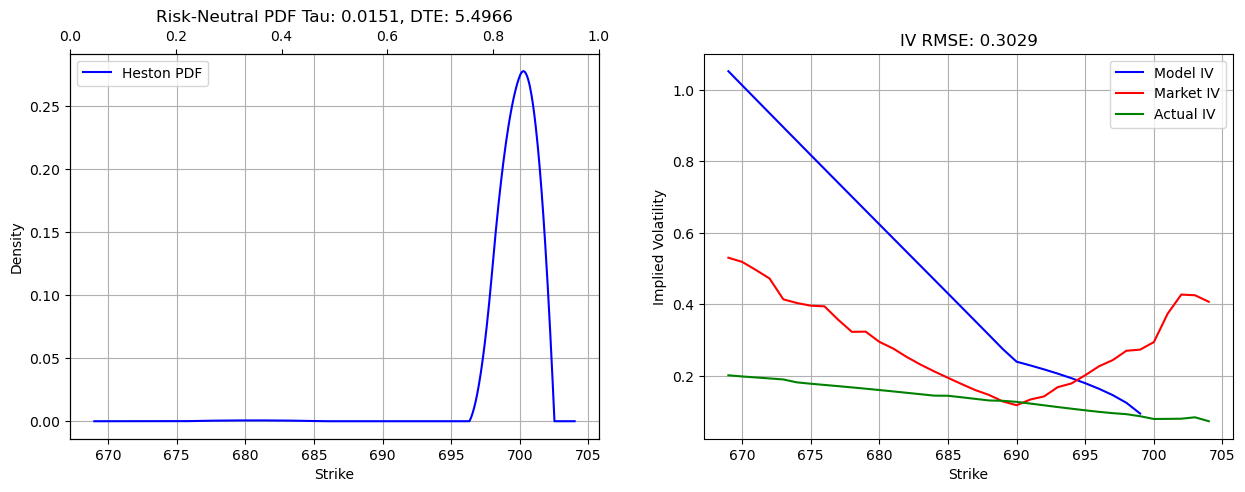

In [12]:
# Extract Pure Market PDF, without model assumptions.
market_pdf = extract_pdf(strikes, market_prices, r, tau, s = 0.05, k = 4)
hpdf = heston_pdf_via_fft(S0, v0, kappa, theta, xi, rho, tau, r, lambd = 0.0, q=q, N=N, L=10)
fig, ax = plt.subplots(1,2,figsize=(15, 5))

ax[0].plot(strikes_pdf, pdf_values, label='Heston PDF', color = 'blue')
twiny = ax[0].twiny()
# twiny.plot(hpdf[0], hpdf[1], label='Heston PDF via FFT', color = 'orange')
ax[0].set_xlabel('Strike')
ax[0].set_ylabel('Density')
ax[0].set_title('Risk-Neutral PDF ' +f'Tau: {tau:.4f}, DTE: {tau * 365:.4f}')
ax[0].grid()
ax[0].legend()

ax[1].plot(strikes, model_ivs, label='Model IV', color='blue')
ax[1].plot(strikes, market_ivs, label='Market IV', color='red')
ax[1].plot(strikes, actual_ivs, label='Actual IV', color='green')
ax[1].set_xlabel('Strike')
ax[1].set_ylabel('Implied Volatility')
ax[1].set_title(f'IV RMSE: {iv_rmse:.4f}')
ax[1].grid()
ax[1].legend()
plt.show()

In [ ]:
hpdf[0].clip()

array([ 0.,  0.,  0., ..., inf, inf, inf])

In [26]:
gcdf['market_iv'] = market_ivs
gcdf['model_iv'] = model_ivs
gcdf['market_price'] = market_prices
gcdf['model_price'] = model_prices


gcdf

,strike,timevalue,lastprice,impliedvolatility,market_iv,model_iv,market_price,model_price
0,669.0,0.015873,9.120000,0.201190,0.529967,1.051646,9.120000,25.497443
1,670.0,0.015873,9.107500,0.197875,0.518409,1.012450,9.107500,24.663625
2,671.0,0.015873,8.765000,0.195115,0.495800,0.973311,8.765000,23.829861
3,672.0,0.015873,8.382500,0.192350,0.471889,0.934227,8.382500,22.996148
4,673.0,0.015873,6.972500,0.189505,0.413608,0.895198,6.972500,22.162489
5,674.0,0.015873,6.991250,0.181303,0.403311,0.856221,6.991250,21.328882
6,675.0,0.015079,7.097000,0.177555,0.395783,0.817295,7.097000,20.495327
7,676.0,0.015079,7.385000,0.174164,0.394044,0.778416,7.385000,19.661824
8,677.0,0.015079,6.582000,0.170784,0.356487,0.739582,6.582000,18.828373
9,678.0,0.015079,5.890000,0.167295,0.322596,0.700789,5.890000,17.994975


In [12]:
forward = S0 * np.exp((r - q) * tau)
print(f"Forward: {forward:.2f}")

# Single test with higher umax / lower alpha
test_prices = heston_call_price_damped(
    S0, strikes, v0, kappa, theta, xi, rho, 0, tau, r,
    alpha=0.25, N=8192, umax=500
)

print("Prices at 689, 695, 700, 705:", test_prices[np.isin(strikes, [689, 695, 700, 705])])

Forward: 690.18
Prices at 689, 695, 700, 705: [0.11537037 0.         0.        ]


In [13]:
# Test with current params
test_params = [3.5460, 0.0364, 0.0251, -0.7484, 0.4506]  # your last good ones
test_prices = heston_call_price_damped(
    S0, strikes, *test_params, lambd=0.0, tau=tau, r=r, q=q,
    alpha=0.1, N=8192, umax=1000
)
print("OTM prices (689+):", test_prices[strikes >= 689])

OTM prices (689+): [2.66747403 2.4051508  2.14290278 1.88072979 1.61863165 1.3566082
 1.09465924 0.8327846  0.57098411 0.30925759 0.04760486 0.
 0.         0.         0.         0.        ]
